# C2 · Taller 4 — DBSCAN: lo que no pertenece a ningún patrón

**Aprendizaje de Máquina · Universidad Sergio Arboleda · Semestre 26-2**
Grupo Shiro — Jose Leonardo Diazgranados, Sofía Londoño, Andrés Felipe Céspedes Rondón, Alex Duran
Docente: Hernán Darío Cruz Bueno · Sector: Energía y Medio Ambiente / IoT

---

## Qué componentes de Shiro decide este taller

K-Means encontró dos tipos de día y el jerárquico confirmó que son reales. Falta la pregunta
inversa: **¿qué no pertenece a ningún patrón?** DBSCAN es el algoritmo hecho para eso, porque no
obliga a cada punto a entrar en un grupo: lo que está en una zona de baja densidad queda como
**ruido**. Dos piezas de Shiro dependen de la respuesta:

| Pieza de Shiro | Pregunta | Parte |
|---|---|---|
| **Gemelo digital y variable «tipo de día» del MDP** | ¿Los dos tipos son grupos densos? ¿Qué días no debería aprender el gemelo como rutina? | **A · días** |
| **Capa Guardian (detector de anomalías)** | Hoy la anomalía es un umbral fijo (p90 del entrenamiento, 200 Wh) que **envejece** (hallazgo 13). ¿Puede la densidad definir «raro» según la hora del día? | **B · lecturas** |

**La secuencia de los tres talleres de clustering:** K-Means encuentra los tipos, el jerárquico los
audita y DBSCAN busca lo que queda fuera.

## Metodología heredada

Semilla 42, las mismas proyecciones PCA/t-SNE de los talleres anteriores y control temporal:
se ajusta con enero–abril y se aplica a mayo, que el modelo no vio (convención §4.2 del proyecto).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

RS = 42
FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
pd.set_option("display.width", 150)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "savefig.bbox": "tight"})
COL = {0: "#1a73e8", 1: "#e8710a", 2: "#188038", "gris": "#5f6368", "claro": "#c7cacf",
       "rojo": "#d93025", "morado": "#a142f4"}

def kdist(V, ms):
    # Distancia de cada punto a su vecino número ms, contándose a sí mismo (la misma cuenta que DBSCAN
    # hace con min_samples): un punto es núcleo si esa distancia es ≤ eps
    return NearestNeighbors(n_neighbors=ms).fit(V).kneighbors(V)[0][:, -1]

def rodilla(kd):
    # El «codo» de la curva de k-distancias ordenada: el punto más alejado de la cuerda que une sus
    # extremos, con ambos ejes normalizados a [0, 1] (versión simplificada del método Kneedle)
    y = np.sort(kd); x = np.arange(len(y))
    xn, yn = x / x[-1], (y - y[0]) / (y[-1] - y[0])
    i = int(np.argmax(xn - yn))
    return y[i], i

def resumen(lab):
    n = len(set(lab)) - (1 if -1 in lab else 0)
    tam = sorted(np.bincount(lab[lab >= 0]).tolist(), reverse=True) if n else []
    return n, int((lab == -1).sum()), tam

---
# Parte A — Días: ¿los tipos de día son grupos densos?

### Pasos 1 y 2 — Columnas y escalado

- **Columnas:** las 24 medias horarias de consumo de cada uno de los 136 días completos, la misma
  matriz de K-Means y del jerárquico, para que los tres métodos se comparen día por día.
- **Escalado:** la versión principal queda **en Wh**, sin estandarizar. Las 24 columnas comparten
  unidad, y el taller del jerárquico mostró que estandarizar amplifica unas 16 veces el ruido de la
  madrugada. Hay además una razón propia de DBSCAN: en Wh, `eps` se puede leer. Un `eps` de 208 Wh en
  24 dimensiones equivale a unos 42 Wh por hora en media cuadrática (208 / √24): «dos días son
  vecinos si difieren en unos 42 Wh por hora».

In [2]:
CSV = "../../data set/energydata_complete.csv"      # ajustar si el cuaderno se mueve de carpeta
df = pd.read_csv(CSV, parse_dates=["date"])
df["dia"] = df["date"].dt.normalize()
df["hora"] = df["date"].dt.hour

lecturas = df.groupby("dia").size()
d = df[df["dia"].isin(lecturas[lecturas == 144].index)].copy()
NIVEL = d.groupby(["dia", "hora"])["Appliances"].mean().unstack()
NIVEL.columns = [f"h{h:02d}" for h in NIVEL.columns]
X = NIVEL.values

info = pd.DataFrame(index=NIVEL.index)
info["dia_semana"] = info.index.day_name().map({"Monday": "lun", "Tuesday": "mar", "Wednesday": "mié",
    "Thursday": "jue", "Friday": "vie", "Saturday": "sáb", "Sunday": "dom"})
info["fin_de_semana"] = (info.index.dayofweek >= 5).astype(int)
info["kwh_dia"] = d.groupby("dia")["Appliances"].sum() / 1000
info["hora_pico"] = X.argmax(axis=1)
info["pico_Wh"] = X.max(axis=1)
info["entrenamiento"] = (info.index <= "2016-04-30").astype(int)

def ordenar(labels, V):
    u = np.unique(labels)
    tot = np.array([V[labels == c].sum(axis=1).mean() for c in u])
    mapa = {u[old]: new for new, old in enumerate(np.argsort(tot))}
    return np.vectorize(mapa.get)(labels)

# Tipos de día del C2-T2 (K-Means, k = 2), recalculados aquí para que el cuaderno corra solo
TIPO = ordenar(KMeans(n_clusters=2, n_init=10, random_state=RS).fit_predict(X), X)
nombres = {0: "día normal", 1: "día de carga alta"}
print(f"Matriz: {X.shape[0]} días × {X.shape[1]} horas (Wh)")
print("Tipos de día (C2-T2):", {nombres[c]: int((TIPO == c).sum()) for c in (0, 1)})

Matriz: 136 días × 24 horas (Wh)
Tipos de día (C2-T2): {'día normal': 108, 'día de carga alta': 28}


### Pasos 3 y 4 — Gráfico de k-distancias y el «codo»

Para cada día se mide la distancia a su vecino número `min_samples`, contándose a sí mismo, que es
la misma cuenta que hace DBSCAN para decidir si un punto es núcleo. Se ordenan de menor a mayor y
se busca el codo: el punto donde la curva pasa de crecer despacio (días en zona densa) a dispararse
(días aislados). El codo se detecta de forma reproducible como el punto más alejado de la cuerda que
une los extremos de la curva, una versión simplificada del método Kneedle.

**Sobre `min_samples`:** la regla habitual pide al menos D + 1 = 25 vecinos, es decir, que un
vecindario mínimo sea el 18 % de los datos. Se prueba, pero la elección principal es
**`min_samples = 5`**, con una lectura directa: *un tipo de día existe si al menos 5 días, una
semana laboral, se parecen entre sí.*

             eps en la rodilla (Wh)  ≈ Wh por hora  clústers  ruido tamaños carga alta en el ruido
min_samples                                                                                       
3                             208.4           42.5         1     52    [84]               28 de 28
4                             207.7           42.4         1     54    [82]               28 de 28
5                             208.2           42.5         1     54    [82]               28 de 28
8                             246.6           50.3         1     48    [88]               28 de 28
12                            381.4           77.9         1     19   [117]               18 de 28
25                            385.7           78.7         1     19   [117]               18 de 28


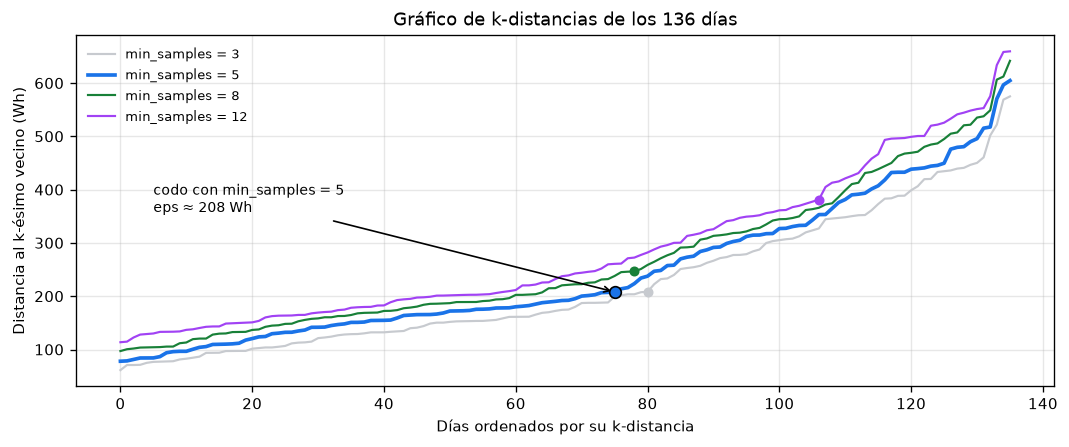

In [3]:
filas = []
for ms in (3, 4, 5, 8, 12, 25):
    eps, _ = rodilla(kdist(X, ms))
    lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
    n, r, tam = resumen(lab)
    filas.append({"min_samples": ms, "eps en la rodilla (Wh)": eps, "≈ Wh por hora": eps / np.sqrt(24),
                  "clústers": n, "ruido": r, "tamaños": tam,
                  "carga alta en el ruido": f"{((lab == -1) & (TIPO == 1)).sum()} de {(TIPO == 1).sum()}"})
print(pd.DataFrame(filas).set_index("min_samples").round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 3.8))
for ms, c in zip((3, 5, 8, 12), (COL["claro"], COL[0], COL[2], COL["morado"])):
    kd = np.sort(kdist(X, ms)); eps, i = rodilla(kd)
    ax.plot(kd, color=c, lw=2.2 if ms == 5 else 1.3, label=f"min_samples = {ms}")
    ax.plot(i, eps, "o", color=c, ms=7 if ms == 5 else 5, mec="black" if ms == 5 else c)
MS = 5
EPS, i5 = rodilla(kdist(X, MS))
ax.annotate(f"codo con min_samples = 5\neps ≈ {EPS:.0f} Wh".replace(".", ","), (i5, EPS), (i5 - 70, EPS + 150),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=8.5)
ax.set(xlabel="Días ordenados por su k-distancia", ylabel="Distancia al k-ésimo vecino (Wh)",
       title="Gráfico de k-distancias de los 136 días")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(FIG / "D1_kdistancias.png"); plt.show()

**El codo es estable para `min_samples` de 3 a 5 (eps ≈ 208 Wh)** y sube con valores mayores (247
con 8, 381 con 12). Incluso con la regla de los 25 vecinos, DBSCAN encuentra **un solo clúster**. En
ningún `min_samples` aparecen dos grupos.

### Pasos 5 y 6 — DBSCAN con los parámetros del codo y visualización

In [4]:
LAB = DBSCAN(eps=EPS, min_samples=MS).fit_predict(X)
n, r, tam = resumen(LAB)
print(f"DBSCAN global · eps = {EPS:.1f} Wh · min_samples = {MS}")
print(f"Clústers: {n} · tamaños {tam} · ruido: {r} días ({r / len(X) * 100:.1f} %)")
print()
print(pd.crosstab(pd.Series(TIPO, name="tipo de día (K-Means)").map(nombres),
                  pd.Series(np.where(LAB == -1, "ruido", "clúster"), name="DBSCAN"), margins=True, margins_name="total").to_string())

DBSCAN global · eps = 208.2 Wh · min_samples = 5
Clústers: 1 · tamaños [82] · ruido: 54 días (39.7 %)

DBSCAN                 clúster  ruido  total
tipo de día (K-Means)                       
día de carga alta            0     28     28
día normal                  82     26    108
total                       82     54    136


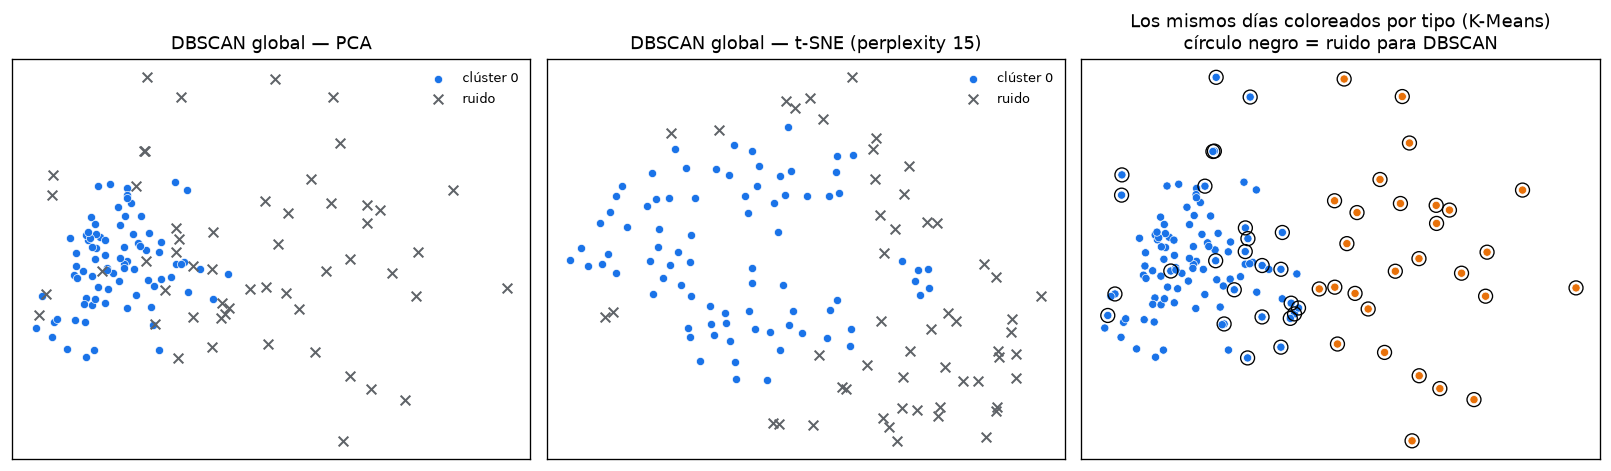

In [5]:
P = PCA(n_components=2).fit_transform(X)
TS = TSNE(n_components=2, perplexity=15, learning_rate=200, init="pca", random_state=RS).fit_transform(X)
ruido = LAB == -1

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
for a, C2, t in ((ax[0], P, "PCA"), (ax[1], TS, "t-SNE (perplexity 15)")):
    a.scatter(C2[~ruido, 0], C2[~ruido, 1], c=COL[0], s=24, edgecolors="white", linewidths=.4, label="clúster 0")
    a.scatter(C2[ruido, 0], C2[ruido, 1], c=COL["gris"], s=34, marker="x", linewidths=1.2, label="ruido")
    a.set(title=f"DBSCAN global — {t}", xticks=[], yticks=[])
    a.legend(frameon=False, fontsize=8)
a = ax[2]
a.scatter(P[:, 0], P[:, 1], c=[COL[t] for t in TIPO], s=24, edgecolors="white", linewidths=.4)
a.scatter(P[ruido, 0], P[ruido, 1], s=70, facecolors="none", edgecolors="black", linewidths=.8)
a.set(title="Los mismos días coloreados por tipo (K-Means)\ncírculo negro = ruido para DBSCAN", xticks=[], yticks=[])
plt.tight_layout(); plt.savefig(FIG / "D2_global.png"); plt.show()

**Un solo gran grupo, que es justo el caso que el enunciado anticipa.** Con `eps = 208 Wh` y
`min_samples = 5`, DBSCAN forma **un clúster de 82 días** y deja **54 como ruido (39,7 %)**. El
cruce con K-Means es la lectura importante: **los 28 días de carga alta caen todos en el ruido**,
junto con 26 días normales.

Para DBSCAN, «día de carga alta» no es un grupo: es la **periferia dispersa** de una única rutina
densa. En PCA se ve lo mismo que en los dos talleres anteriores: un núcleo apretado a la izquierda y
los días de carga alta repartidos hacia la derecha, sin la densidad que DBSCAN exige para llamarlos
grupo. K-Means y el jerárquico los agrupaban porque están obligados a asignar cada día a algún
clúster; DBSCAN no tiene esa obligación.

### «Si da todo como un gran grupo, hay que separar por grupos» — y cuáles grupos es una decisión

**Decisión: separar por tipo de día** (K-Means, validado por el jerárquico). Es la única agrupación
que el proyecto ya justificó con datos. La alternativa obvia, el calendario, se corre como contraste,
porque el taller de K-Means midió que no explica el consumo (V de Cramér = 0,000). Cada grupo recibe
**su propio `eps`**, tomado del codo de su propia curva de k-distancias.

In [6]:
def por_grupos(grupo, nombres_g, ms=MS):
    etiqueta = np.full(len(X), -1)
    filas, base = [], 0
    for g in np.unique(grupo):
        idx = np.where(grupo == g)[0]
        eps_g, _ = rodilla(kdist(X[idx], ms))
        lab = DBSCAN(eps=eps_g, min_samples=ms).fit_predict(X[idx])
        n, r, tam = resumen(lab)
        etiqueta[idx[lab >= 0]] = lab[lab >= 0] + base; base += max(n, 0)
        filas.append({"grupo": nombres_g[g], "días": len(idx), "eps rodilla (Wh)": eps_g,
                      "clústers": n, "tamaños": tam, "ruido": r,
                      "carga alta en el ruido": int(((lab == -1) & (TIPO[idx] == 1)).sum())})
    return pd.DataFrame(filas).set_index("grupo"), etiqueta

res_tipo, ETQ_TIPO = por_grupos(TIPO, nombres)
res_finde, ETQ_FINDE = por_grupos(info["fin_de_semana"].values, {0: "laborable", 1: "fin de semana"})
print("Separando por TIPO DE DÍA (la decisión):"); print(res_tipo.round(1).to_string())
print(f"→ Los días de carga alta están {res_tipo.iloc[1]['eps rodilla (Wh)'] / res_tipo.iloc[0]['eps rodilla (Wh)']:.1f} veces más dispersos")
print("\nSeparando por CALENDARIO (contraste):"); print(res_finde.round(1).to_string())

Separando por TIPO DE DÍA (la decisión):
                   días  eps rodilla (Wh)  clústers tamaños  ruido  carga alta en el ruido
grupo                                                                                     
día normal          108             208.2         1    [82]     26                       0
día de carga alta    28             452.3         1    [24]      4                       4
→ Los días de carga alta están 2.2 veces más dispersos

Separando por CALENDARIO (contraste):
               días  eps rodilla (Wh)  clústers tamaños  ruido  carga alta en el ruido
grupo                                                                                 
laborable        98             190.4         1    [54]     44                      20
fin de semana    38             365.2         1    [30]      8                       7


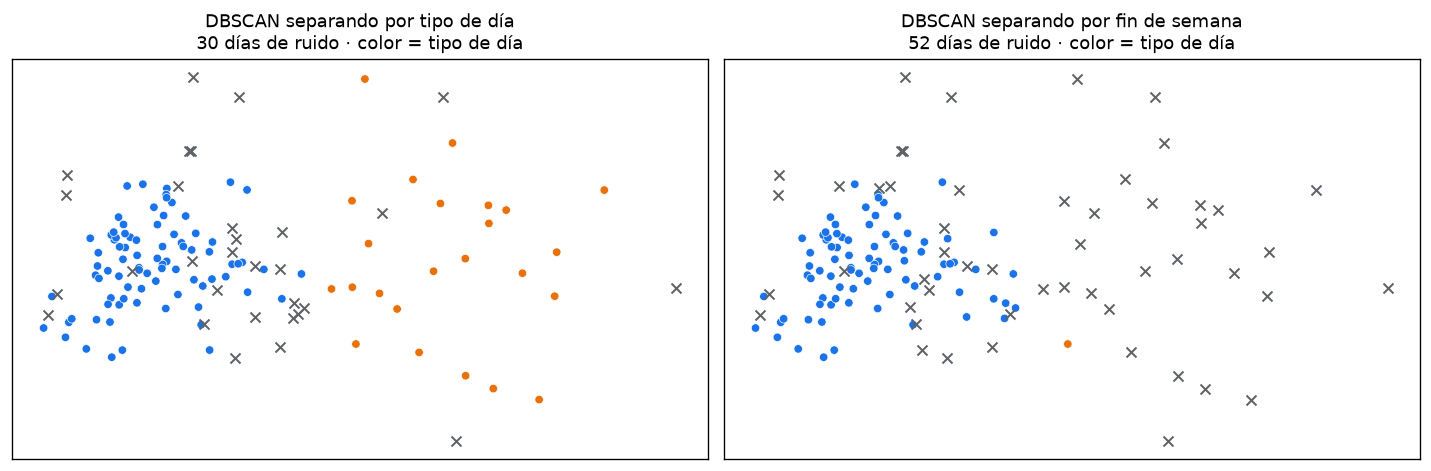

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, (etq, titulo) in zip(ax, ((ETQ_TIPO, "separando por tipo de día"), (ETQ_FINDE, "separando por fin de semana"))):
    r = etq == -1
    colores = [COL[TIPO[i]] for i in range(len(X))]
    a.scatter(P[~r, 0], P[~r, 1], c=[colores[i] for i in np.where(~r)[0]], s=26, edgecolors="white", linewidths=.4)
    a.scatter(P[r, 0], P[r, 1], c=COL["gris"], s=36, marker="x", linewidths=1.2)
    a.set(title=f"DBSCAN {titulo}\n{r.sum()} días de ruido · color = tipo de día", xticks=[], yticks=[])
plt.tight_layout(); plt.savefig(FIG / "D3_por_grupos.png"); plt.show()

**Cada tipo de día tiene su propia densidad, y eso es un resultado.** El codo de los días normales
queda en 208 Wh y el de los días de carga alta en **452 Wh: son 2,2 veces más dispersos.** Con su
propio `eps`, **24 de los 28 días de carga alta sí forman un grupo** y solo 4 quedan como ruido. En
total, 30 días de ruido en lugar de 54.

Es la limitación clásica de DBSCAN: un único `eps` no sirve para grupos de densidades distintas. Con
el `eps` de los días normales, los de carga alta parecen ruido; con el suyo, son un grupo.

**Separar por calendario no resuelve nada:** 52 días de ruido y **27 de los 28 días de carga alta
siguen en el ruido**. Lo confirma por segunda vez: el tipo de día no lo decide el calendario.

**Para Shiro:** el día de carga alta es un tipo real, pero **mucho menos repetible** que el día
normal. El simulador no puede declarar la misma incertidumbre los dos días. El hallazgo 14 ya pedía
una incertidumbre por franja horaria; ahora también debe depender del tipo de día.

### Paso 7 — ¿Cómo cambia el resultado si se ajustan `eps` y `min_samples`?

Se recorre una rejilla de 21 valores de `eps` (100 a 600 Wh) por 7 de `min_samples` (3 a 12): 147
configuraciones, todas sobre los 136 días.

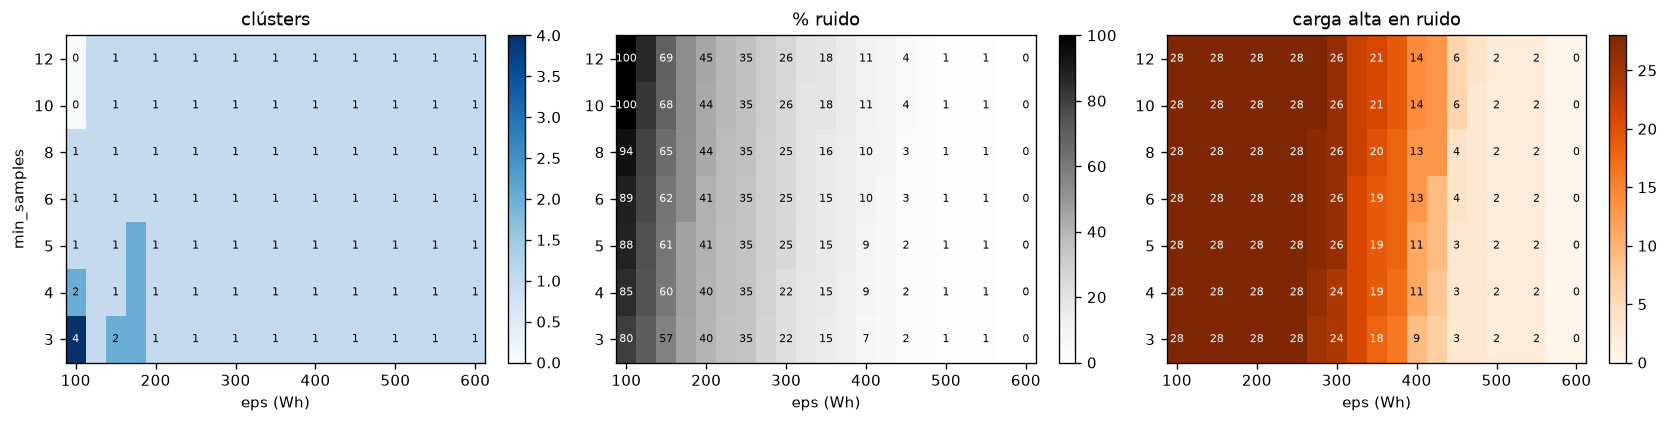

Máximo número de clústers en toda la rejilla: 4
Configuraciones con 2 o más clústers: 6 de 147
  eps=100 ms=3 → (4, 109, [16, 4, 4, 3])
  eps=150 ms=3 → (2, 78, [55, 3])
  eps=175 ms=3 → (2, 62, [68, 6])
  eps=100 ms=4 → (2, 116, [16, 4])
  eps=175 ms=4 → (2, 63, [67, 6])
  eps=175 ms=5 → (2, 63, [67, 6])


In [8]:
EPS_GRID = np.arange(100, 601, 25)
MS_GRID = [3, 4, 5, 6, 8, 10, 12]
M = {k: np.zeros((len(MS_GRID), len(EPS_GRID))) for k in ("clústers", "% ruido", "carga alta en ruido")}
for i, ms in enumerate(MS_GRID):
    for j, e in enumerate(EPS_GRID):
        lab = DBSCAN(eps=e, min_samples=ms).fit_predict(X)
        M["clústers"][i, j] = resumen(lab)[0]
        M["% ruido"][i, j] = (lab == -1).mean() * 100
        M["carga alta en ruido"][i, j] = ((lab == -1) & (TIPO == 1)).sum()

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, (k, cmap) in zip(ax, (("clústers", "Blues"), ("% ruido", "Greys"), ("carga alta en ruido", "Oranges"))):
    im = a.imshow(M[k], aspect="auto", cmap=cmap, origin="lower")
    a.set_xticks(range(0, len(EPS_GRID), 4)); a.set_xticklabels(EPS_GRID[::4])
    a.set_yticks(range(len(MS_GRID))); a.set_yticklabels(MS_GRID)
    a.set(xlabel="eps (Wh)", title=k); a.grid(False)
    for i in range(len(MS_GRID)):
        for j in range(0, len(EPS_GRID), 2):
            v = M[k][i, j]
            a.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6.5,
                   color="white" if v > np.nanmax(M[k]) * .6 else "black")
    plt.colorbar(im, ax=a, fraction=.04)
ax[0].set_ylabel("min_samples")
plt.tight_layout(); plt.savefig(FIG / "D4_sensibilidad.png"); plt.show()

print("Máximo número de clústers en toda la rejilla:", int(M["clústers"].max()))
dos = np.argwhere(M["clústers"] >= 2)
print("Configuraciones con 2 o más clústers:", len(dos), "de", M["clústers"].size)
for i, j in dos[:12]:
    lab = DBSCAN(eps=EPS_GRID[j], min_samples=MS_GRID[i]).fit_predict(X)
    print(f"  eps={EPS_GRID[j]} ms={MS_GRID[i]} → {resumen(lab)}")

**`eps` manda y `min_samples` apenas desplaza la frontera.**

- **eps < 175 Wh:** DBSCAN fragmenta. Aparecen hasta 4 clústers, pero de 3 a 16 días y con entre 62
  y 116 días de ruido.
- **eps entre 200 y 250 Wh (la zona del codo):** un grupo con los días normales. Los 28 de carga
  alta, en el ruido.
- **eps entre 300 y 400 Wh:** los días de carga alta empiezan a entrar al grupo único.
- **eps ≥ 450 Wh:** casi todo se absorbe en un único clúster, con el 2 % de ruido o menos.

**En las 147 configuraciones, DBSCAN nunca separa los dos tipos de día como dos grupos.** Solo 6
producen más de un clúster, y en todas el segundo grupo tiene de 3 a 6 días. Subir `min_samples`
exige más vecinos y mueve el mismo patrón hacia `eps` mayores.

### ¿Qué días son atípicos de verdad, y no por una elección de parámetros?

Un día que es ruido en una sola configuración puede ser un accidente del `eps`. Se define un
**atípico robusto**: dentro de su tipo de día, es ruido en al menos el 80 % de 25 configuraciones
(5 valores de `min_samples`, de 3 a 8, por 5 valores de `eps`, del 80 % al 120 % del codo).

In [9]:
FACT, MSR = (0.8, 0.9, 1.0, 1.1, 1.2), (3, 4, 5, 6, 8)
veces = np.zeros(len(X))
for t in (0, 1):
    idx = np.where(TIPO == t)[0]
    for ms in MSR:
        eps_t, _ = rodilla(kdist(X[idx], ms))
        for f in FACT:
            veces[idx] += DBSCAN(eps=eps_t * f, min_samples=ms).fit_predict(X[idx]) == -1
info["frac_ruido"] = veces / (len(FACT) * len(MSR))
ROBUSTO = info["frac_ruido"].values >= 0.8

mediana_tipo = {t: np.median(X[TIPO == t], axis=0) for t in (0, 1)}
dev = np.vstack([X[i] - mediana_tipo[TIPO[i]] for i in range(len(X))])
info["tipo"] = [nombres[t] for t in TIPO]
info["hora_mayor_desvio"] = np.abs(dev).argmax(axis=1)
info["desvio_Wh"] = dev[np.arange(len(X)), info["hora_mayor_desvio"]]
print(f"Días de ruido en al menos el 80 % de las {len(FACT) * len(MSR)} configuraciones: {ROBUSTO.sum()}")
print(info.loc[ROBUSTO, ["tipo", "dia_semana", "kwh_dia", "hora_pico", "pico_Wh", "hora_mayor_desvio",
                         "desvio_Wh", "frac_ruido"]].sort_values(["tipo", "frac_ruido"], ascending=[True, False]).round(2).to_string())
print(f"\nPor tipo: {pd.Series(TIPO[ROBUSTO]).map(nombres).value_counts().to_dict()}")
MESES = {1: "ene", 2: "feb", 3: "mar", 4: "abr", 5: "may"}
print("Por mes (atípicos robustos / días del mes):",
      {MESES[m]: f"{(info.index[ROBUSTO].month == m).sum()}/{(info.index.month == m).sum()}" for m in range(1, 6)})
h_ev = (np.abs(dev) > 100).sum(axis=1)
print(f"Horas con más de 100 Wh de desvío respecto de la mediana de su tipo: mediana {np.median(h_ev[ROBUSTO]):.0f} "
      f"en los atípicos robustos · {np.median(h_ev[~ROBUSTO]):.0f} en el resto de los días")
print(f"Desvío de la peor hora: mediana {np.median(np.abs(info['desvio_Wh'][ROBUSTO])):.0f} Wh en los atípicos · "
      f"{np.median(np.abs(info['desvio_Wh'][~ROBUSTO])):.0f} Wh en el resto")

Días de ruido en al menos el 80 % de las 25 configuraciones: 22
                         tipo dia_semana  kwh_dia  hora_pico  pico_Wh  hora_mayor_desvio  desvio_Wh  frac_ruido
dia                                                                                                            
2016-01-24  día de carga alta        dom    21.64          8   608.33                  8     470.00        0.92
2016-03-16  día de carga alta        mié    22.81         18   563.33                 18     355.83        0.88
2016-01-13         día normal        mié    13.97         21   313.33                 21     228.33        1.00
2016-01-15         día normal        vie    18.05         18   278.33                  8     170.00        1.00
2016-01-16         día normal        sáb    18.04         18   473.33                 18     318.33        1.00
2016-01-18         día normal        lun    13.53         20   558.33                 20     450.00        1.00
2016-02-15         día normal        lun

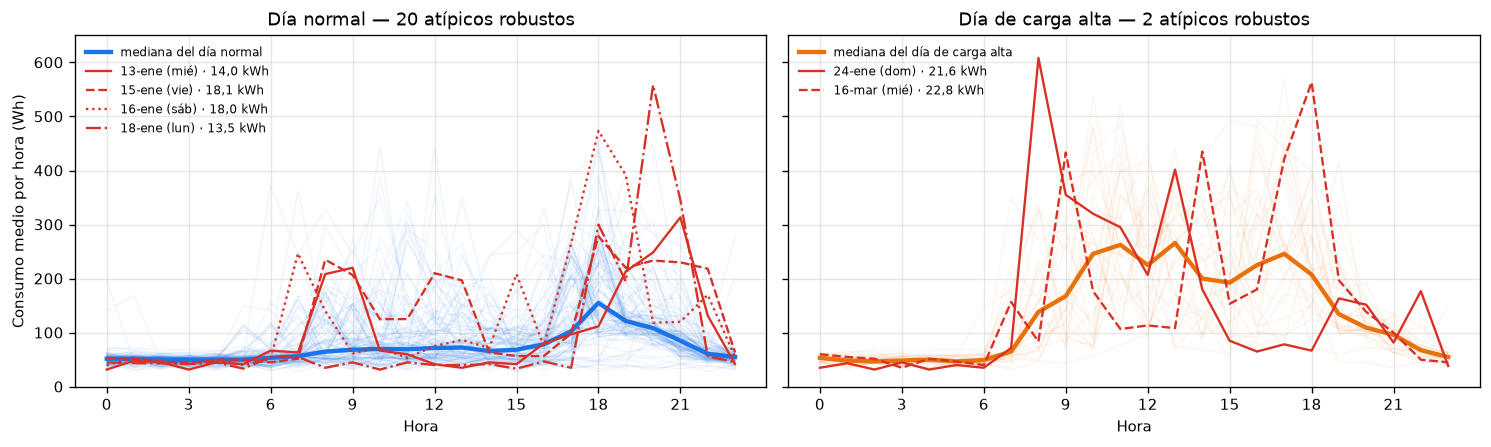

In [10]:
horas = np.arange(24)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8), sharey=True)
for a, t in zip(ax, (0, 1)):
    for i in np.where(TIPO == t)[0]:
        a.plot(horas, X[i], color=COL[t], alpha=.07, lw=.8)
    a.plot(horas, mediana_tipo[t], color=COL[t], lw=2.6, label=f"mediana del {nombres[t]}")
    rob = np.where(ROBUSTO & (TIPO == t))[0]
    for j, i in enumerate(rob[np.argsort(-info["frac_ruido"].values[rob])][:4]):
        a.plot(horas, X[i], color=COL["rojo"], lw=1.4, ls=["-", "--", ":", "-."][j],
               label=f"{NIVEL.index[i].day:02d}-{MESES[NIVEL.index[i].month]} ({info.dia_semana.iloc[i]}) · "
                     f"{info.kwh_dia.iloc[i]:.1f} kWh".replace(".", ","))
    a.set(title=f"{nombres[t].capitalize()} — {len(rob)} atípicos robustos", xlabel="Hora",
          xticks=range(0, 24, 3), ylim=(0, 650))
    a.legend(frameon=False, fontsize=7.3, loc="upper left")
ax[0].set_ylabel("Consumo medio por hora (Wh)")
plt.tight_layout(); plt.savefig(FIG / "D5_atipicos.png"); plt.show()

**22 días (16 %) son atípicos robustos: 20 normales y 2 de carga alta.** Los tres días que el
jerárquico había dejado aislados, 24-ene, 16-mar y 15-abr, están entre ellos. Es la misma señal,
encontrada por dos métodos distintos.

**Qué tienen en común:** no es un solo pico. Tienen una mediana de **4 horas** con más de 100 Wh por
encima de la mediana de su tipo, frente a 1 hora en el resto de los días, y su peor hora se desvía
285 Wh, frente a 144. Son días con varias horas muy cargadas, sin una hora fija: la peor hora va de
las 6 a las 21 h según el día.

**Y se concentran en enero: 8 de sus 20 días son atípicos (40 %)**, frente a 4 de 29 en febrero, 4 de
31 en marzo, 5 de 30 en abril y 1 de 26 en mayo. Es la huella de la estación que el parcial encontró
en el umbral (p90 de 250 Wh en enero y de 150 en mayo): los días «normales» de enero consumen más que
los normales del resto del periodo, y DBSCAN los ve dispersos.

**Para Shiro:** «atípico» no significa «descartable». Un 16 % de los días no se puede tirar, y la
mitad de ellos serían de enero, así que el gemelo perdería justo el invierno. Los atípicos robustos
se **marcan**: el agente no debe confiar en su estimación del tipo de día en esos días, pero el
simulador los necesita para aprender la estación.

### Control temporal: ¿mayo trae días desconocidos?

Se ajusta todo con los 110 días hasta el 30 de abril: los tipos de día con K-Means y DBSCAN dentro de
cada tipo, cada uno con su `eps`. Cada día de mayo se asigna a su tipo por el centroide más cercano, y
se declara **desconocido** si no tiene ningún punto núcleo de su tipo a menos de `eps`. Así DBSCAN
funciona como detector de novedad.

In [11]:
tr = info["entrenamiento"].values == 1
Xtr, Xmy = X[tr], X[~tr]
km_tr = KMeans(n_clusters=2, n_init=10, random_state=RS).fit(Xtr)
t_tr = ordenar(km_tr.labels_, Xtr)
cen = np.vstack([Xtr[t_tr == c].mean(axis=0) for c in (0, 1)])
t_my = np.linalg.norm(Xmy[:, None, :] - cen[None], axis=2).argmin(axis=1)

filas, desconocido = [], np.zeros(len(Xmy), bool)
for t in (0, 1):
    V = Xtr[t_tr == t]
    eps_t, _ = rodilla(kdist(V, MS))
    db = DBSCAN(eps=eps_t, min_samples=MS).fit(V)
    nucleos = V[db.core_sample_indices_]
    m = t_my == t
    dist = NearestNeighbors(n_neighbors=1).fit(nucleos).kneighbors(Xmy[m])[0][:, 0]
    desconocido[np.where(m)[0]] = dist > eps_t
    filas.append({"tipo": nombres[t], "eps (Wh)": eps_t, "ruido ene–abr": f"{(db.labels_ == -1).mean() * 100:.1f} %",
                  "días de mayo asignados": int(m.sum()), "sin núcleo a < eps («desconocidos»)": int((dist > eps_t).sum())})
print(pd.DataFrame(filas).set_index("tipo").round(1).to_string())
print(f"\nMayo: {desconocido.sum()} de {len(Xmy)} días desconocidos para el gemelo")
print(info.loc[~tr].loc[desconocido, ["dia_semana", "kwh_dia", "hora_pico", "pico_Wh"]].assign(
    tipo=[nombres[t] for t in t_my[desconocido]]).round(1).to_string())

                   eps (Wh) ruido ene–abr  días de mayo asignados  sin núcleo a < eps («desconocidos»)
tipo                                                                                                  
día normal            223.8        24.7 %                      23                                    2
día de carga alta     462.1        16.0 %                       3                                    0

Mayo: 2 de 26 días desconocidos para el gemelo
           dia_semana  kwh_dia  hora_pico  pico_Wh        tipo
dia                                                           
2016-05-06        vie     14.5          9    273.3  día normal
2016-05-22        dom     15.9         11    343.3  día normal


**Solo 2 de los 26 días de mayo (7,7 %) son desconocidos para el gemelo**: el viernes 6 (14,5 kWh,
con el pico a las 9 h) y el domingo 22 (15,9 kWh, con el pico a las 11 h), ambos asignados al tipo
normal y con mañanas cargadas. Es coherente con el taller de K-Means, que tampoco encontró rutinas
nuevas en mayo (0 de 26 días más allá del p95). Mayo no trae tipos de día nuevos, sino menos días de
carga alta.

En Shiro, «día desconocido» es una señal útil y barata. Si el día que está viviendo el agente no
tiene vecinos densos en su historia, la política debería volverse conservadora, porque el simulador
no ha visto nada parecido.

---
# Parte B — Lecturas de 10 minutos: la anomalía contextual para Guardian

El detector del proyecto marca como anomalía toda lectura por encima de 200 Wh (el p90 del
entrenamiento, convención §4.3). Tiene dos problemas medidos. El umbral **envejece**, porque el p90
mensual cae de 250 a 150 Wh entre enero y mayo. Y es **ciego al contexto**: 150 Wh a las 3 de la
mañana y 150 Wh a las 7 de la tarde valen lo mismo. La pregunta de esta parte es si la densidad puede
definir «raro para su momento».

Todo se ajusta con **enero–abril** y mayo queda como control.

In [12]:
dl = df.sort_values("date").reset_index(drop=True)
dl["dia_semana"] = dl["date"].dt.dayofweek
dl["es_fin_semana"] = (dl["dia_semana"] >= 5).astype(int)
dl["mes"] = dl["date"].dt.month
# Retardos del parcial (shift(1): nunca miran el presente), sobre la serie tal como la entrega el medidor
dl["lag1"] = dl["Appliances"].shift(1)
dl["media_1h"] = dl["Appliances"].shift(1).rolling(6).mean()
dl["std_1h"] = dl["Appliances"].shift(1).rolling(6).std()
# Misma construcción sobre la serie con «dithering»: ±5 Wh uniformes, dentro de la resolución de 10 Wh del
# medidor (se justifica en §B.2). Las columnas originales se conservan para reportar y para el umbral.
rng = np.random.default_rng(RS)
dl["A_d"] = dl["Appliances"] + rng.uniform(-5, 5, len(dl))
dl["lag1_d"] = dl["A_d"].shift(1)
dl["media_1h_d"] = dl["A_d"].shift(1).rolling(6).mean()
dl["std_1h_d"] = dl["A_d"].shift(1).rolling(6).std()
dl["franja"] = pd.cut(dl["hora"], [-1, 5, 11, 17, 23], labels=["madrugada", "mañana", "tarde", "noche"])
dl = dl.dropna().reset_index(drop=True)

# Umbral de anomalía de la convención del proyecto (§4.3): p90 del entrenamiento de la partición aleatoria
UMBRAL = np.percentile(train_test_split(df["Appliances"], test_size=.2, random_state=RS)[0], 90)
TR = (dl["date"] < "2016-05-01").values                 # enero–abril: se ajusta aquí; mayo es el control
ALTO = (dl["Appliances"] > UMBRAL).values
print(f"Lecturas: {len(dl):,} · enero–abril {TR.sum():,} · mayo {(~TR).sum():,}".replace(",", "."))
print(f"Umbral de anomalía (convención): {UMBRAL:.0f} Wh · lecturas por encima en ene–abr: {ALTO[TR].mean() * 100:.1f} % · en mayo: {ALTO[~TR].mean() * 100:.1f} %")

Lecturas: 19.729 · enero–abril 15.876 · mayo 3.853
Umbral de anomalía (convención): 200 Wh · lecturas por encima en ene–abr: 10.2 % · en mayo: 7.6 %


### Paso 1, primer intento — todas las columnas numéricas

Lo más directo es tomar las 29 variables predictoras más el consumo, estandarizarlas y aplicar
DBSCAN. Con 30 dimensiones se usa `min_samples = 2 · 30 = 60`.

In [13]:
INTERIOR = [f"T{i}" for i in range(1, 10)] + [f"RH_{i}" for i in range(1, 10)]
CLIMA = ["T_out", "RH_out", "Press_mm_hg", "Windspeed", "Visibility", "Tdewpoint"]
TODAS = ["hora", "dia_semana", "es_fin_semana", "mes", "lights"] + INTERIOR + CLIMA + ["Appliances"]
V30 = StandardScaler().fit(dl.loc[TR, TODAS]).transform(dl.loc[TR, TODAS])
ms30 = 2 * len(TODAS)
eps30, _ = rodilla(kdist(V30, ms30))
fechas = dl.loc[TR, "date"].dt.normalize().values
for f in (1.0, 0.5):
    lab = DBSCAN(eps=eps30 * f, min_samples=ms30).fit_predict(V30)
    n, r, tam = resumen(lab)
    print(f"{len(TODAS)} columnas · min_samples = {ms30} · eps = {eps30 * f:.2f} ({f:.0%} del codo) → "
          f"{n} clústers · ruido {r / len(lab) * 100:.1f} %")
    if f == 0.5:
        LAB30 = lab
g = pd.DataFrame({"clúster": LAB30, "fecha": fechas})
g = g[g["clúster"] >= 0].groupby("clúster")["fecha"].agg(["size", "min", "max", "nunique"])
g["días que abarca"] = (g["max"] - g["min"]).dt.days + 1
g = g.sort_values("size", ascending=False)
print(f"\nLos 8 clústers más grandes con eps a la mitad del codo:")
print(g.head(8).rename(columns={"size": "lecturas", "min": "desde", "max": "hasta", "nunique": "días distintos"}).to_string())
print(f"\nClústers que caben en una ventana de 7 días o menos: {(g['días que abarca'] <= 7).sum()} de {len(g)}")

30 columnas · min_samples = 60 · eps = 4.06 (100% del codo) → 1 clústers · ruido 0.7 %


30 columnas · min_samples = 60 · eps = 2.03 (50% del codo) → 30 clústers · ruido 78.4 %

Los 8 clústers más grandes con eps a la mitad del codo:
         lecturas      desde      hasta  días distintos  días que abarca
clúster                                                                 
21            613 2016-03-21 2016-04-13              13               24
3             225 2016-01-19 2016-01-22               4                4
5             193 2016-01-26 2016-01-27               2                2
9             143 2016-02-04 2016-02-05               2                2
16            130 2016-03-03 2016-03-04               2                2
24            122 2016-04-09 2016-04-17               3                9
26            109 2016-04-19 2016-04-21               3                3
2             109 2016-01-18 2016-01-19               2                2

Clústers que caben en una ventana de 7 días o menos: 26 de 30


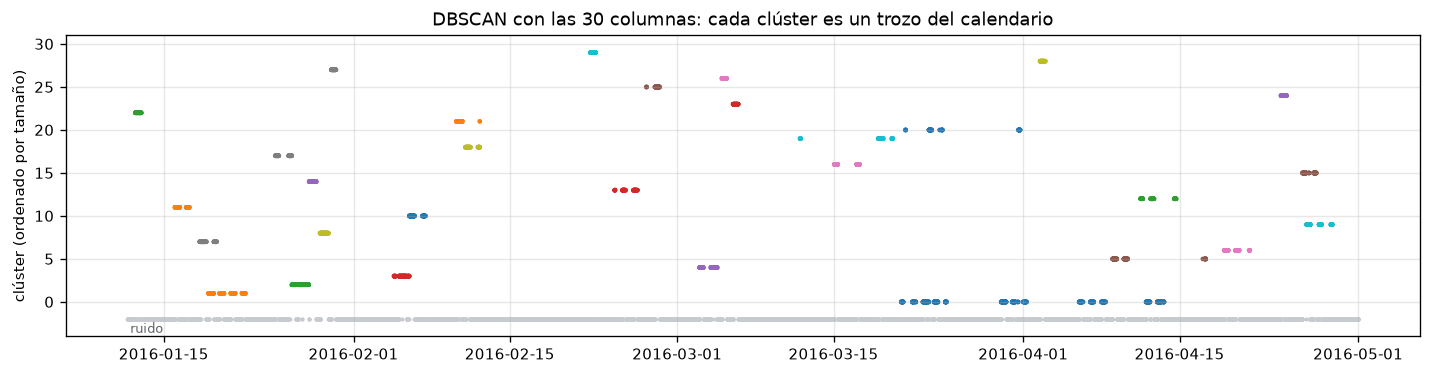

In [14]:
fig, ax = plt.subplots(figsize=(12, 3.2))
orden = {c: i for i, c in enumerate(g.index)}
m = LAB30 >= 0
y = np.array([orden.get(c, -1) for c in LAB30[m]])
ax.scatter(pd.to_datetime(dl.loc[TR, "date"].values[m]), y, c=y % 10, cmap="tab10", s=3)
ax.scatter(pd.to_datetime(dl.loc[TR, "date"].values[~m]), np.full((~m).sum(), -2), c=COL["claro"], s=2)
ax.set(ylabel="clúster (ordenado por tamaño)", title=f"DBSCAN con las {len(TODAS)} columnas: cada clúster es un trozo del calendario",
       ylim=(-4, len(g) + 1))
ax.text(pd.Timestamp("2016-01-12"), -3.6, "ruido", color=COL["gris"], fontsize=7.5)
plt.tight_layout(); plt.savefig(FIG / "D6_todas_semanas.png"); plt.show()

**Con las 30 columnas, DBSCAN agrupa semanas, no comportamientos.** En el codo sale un solo
clúster con un 0,7 % de ruido. Con la mitad de ese `eps`, el grupo se rompe en 30 clústers, y **26 de
ellos caben en una ventana de 7 días o menos**. El mayor va del 21-mar al 13-abr. Cada clúster es un
trozo del calendario.

La razón está en dos advertencias del proyecto. Las lecturas consecutivas son casi idénticas
(autocorrelación, §8 de `CLAUDE.md`), así que DBSCAN encadena el tiempo. Además, las 18 variables de
sensores interiores derivan con la estación (hallazgo 18) y dominan la distancia. Lo que DBSCAN
encuentra es **en qué semana está la casa**, no qué está haciendo. **La selección de variables es la
decisión que manda.**

### Paso 1, decisión — consumo y retardos

Para detectar un consumo raro hay que describir **el consumo y su dinámica**. Se usan `Appliances` y
los retardos del parcial, que fueron la ingeniería de variables que más rindió en todo el proyecto:
`lag1` (la lectura anterior), `media_1h` y `std_1h` (media y desviación de la última hora, siempre
con `shift(1)`). Se aplica `log1p` porque la cola del consumo es larga (10 a 1.080 Wh) y luego
`StandardScaler`, ajustado solo con enero–abril (paso 2). Con 4 dimensiones, `min_samples = 8`.

In [15]:
DIN = ["Appliances", "lag1", "media_1h", "std_1h"]
MSD = 2 * len(DIN)
V0 = StandardScaler().fit(np.log1p(dl.loc[TR, DIN])).transform(np.log1p(dl.loc[TR, DIN]))
eps0, _ = rodilla(kdist(V0, MSD))
lab0 = DBSCAN(eps=eps0, min_samples=MSD).fit_predict(V0)
n, r, tam = resumen(lab0)
print(f"SIN CORREGIR · consumo + retardos (log1p + estandarizado) · min_samples = {MSD} · eps = {eps0:.3f}")
print(f"{n} clústers · tamaños {tam[:6]} · ruido {r / len(lab0) * 100:.1f} %\n")
t0 = dl.loc[TR, ["Appliances"]].assign(clúster=lab0)
capas = t0[t0["clúster"] >= 0].groupby("clúster")["Appliances"].agg(["size", "min", "max"]).sort_values("size", ascending=False)
print("Consumo de cada clúster (Wh) — los pequeños son capas de un solo valor:")
print(capas.rename(columns={"size": "lecturas"}).to_string())
print(f"\nClústers que contienen un único valor de consumo: {(capas['min'] == capas['max']).sum()} de {len(capas)}")
print(f"Lecturas que son múltiplos exactos de 10 Wh: {(dl['Appliances'] % 10 == 0).mean() * 100:.0f} %")

SIN CORREGIR · consumo + retardos (log1p + estandarizado) · min_samples = 8 · eps = 0.382
14 clústers · tamaños [13830, 336, 327, 212, 117, 116] · ruido 3.4 %

Consumo de cada clúster (Wh) — los pequeños son capas de un solo valor:
         lecturas  min  max
clúster                    
0           13830   40  910
1             336   30   30
2             327   40   80
7             212   30   30
3             117   20   20
6             116   30   30
5              99   40   60
4              96   20   20
8              92   20   20
9              60   40   90
10             25   40   70
11             10  360  410
13              9  170  220
12              7   60   70

Clústers que contienen un único valor de consumo: 6 de 14
Lecturas que son múltiplos exactos de 10 Wh: 100 %


### Un artefacto que hay que corregir antes de interpretar: la resolución del medidor

**El 100 % de las lecturas son múltiplos exactos de 10 Wh.** El medidor redondea. En consumos bajos,
`log1p` separa esos escalones (de 20 a 30 Wh hay más distancia en escala logarítmica que de 500 a
510), y miles de lecturas idénticas forman **capas de densidad artificial**. Los clústers pequeños de
arriba no son comportamientos: **6 de los 14 contienen un único valor de consumo** (20 o 30 Wh
exactos) y el resto, franjas estrechas de valores bajos.

**Corrección: dithering.** Se suma a cada lectura un ruido uniforme de ±5 Wh, que es exactamente la
incertidumbre de un medidor con resolución de 10 Wh. No añade información ni la quita: devuelve a
cada lectura el rango de valores que realmente pudo tener. Los retardos se recalculan sobre la serie
corregida y las cifras reportadas siguen usando el consumo original.

Se compara también la versión **sin logaritmo**, porque la transformación decide qué significa
«raro».

In [16]:
def espacio(cols, transformar):
    esc = StandardScaler().fit(transformar(dl.loc[TR, cols]))
    return esc.transform(transformar(dl[cols]))              # todo el periodo, con el escalador de ene–abr

DIN_D = ["A_d", "lag1_d", "media_1h_d", "std_1h_d"]
filas = []
for nombre, f in (("log1p (elegida)", np.log1p), ("sin logaritmo", lambda v: v)):
    V = espacio(DIN_D, f)
    e, _ = rodilla(kdist(V[TR], MSD))
    lab = DBSCAN(eps=e, min_samples=MSD).fit_predict(V[TR]); rg = lab == -1
    n, r, tam = resumen(lab)
    filas.append({"transformación": nombre, "eps": e, "clústers": n, "tamaños": tam[:5],
                  "% ruido": rg.mean() * 100, "% del ruido sobre el umbral": ALTO[TR][rg].mean() * 100,
                  "% de lecturas > umbral en el ruido": rg[ALTO[TR]].mean() * 100})
    if nombre.startswith("log1p"):
        VD, eps_g, lab_g = V, e, lab
print("CON DITHERING (±5 Wh):")
print(pd.DataFrame(filas).set_index("transformación").round(3).to_string())
rg = lab_g == -1
print("\nReparto del ruido global por franja (%):", dl.loc[TR].loc[rg, "franja"].value_counts(normalize=True).mul(100).round(0).to_dict())

CON DITHERING (±5 Wh):
                   eps  clústers                 tamaños  % ruido  % del ruido sobre el umbral  % de lecturas > umbral en el ruido
transformación                                                                                                                    
log1p (elegida)  0.364         7   [15114, 40, 17, 9, 9]    4.239                       46.657                              19.359
sin logaritmo    0.533         8  [15009, 29, 13, 11, 9]    4.926                       79.795                              38.471

Reparto del ruido global por franja (%): {'mañana': 38.0, 'tarde': 33.0, 'noche': 27.0, 'madrugada': 3.0}


**Con la corrección, aparece el caso del enunciado: un gran grupo.** Un clúster reúne el 95 % de las
lecturas (15.114). Quedan otros 6 de 40 lecturas o menos y un 4,2 % de ruido.

**La transformación decide qué es raro.** Sin logaritmo, el 80 % del ruido está por encima del
umbral: «raro» significa «grande», y DBSCAN solo repite el umbral. Con `log1p`, solo el 47 % lo está.
El resto son lecturas modestas en momentos inusuales. Se elige `log1p`, porque para eso se usa
DBSCAN aquí.

Pero incluso así, el ruido global se reparte casi todo entre mañana (38 %), tarde (33 %) y noche
(27 %), y **la madrugada, con el 3 %, casi desaparece**. Un solo `eps` para todo el día compara la
madrugada con la tarde.

### Separar por grupos: la decisión es la franja horaria

**Decisión: separar por franja** (madrugada 0–6 h, mañana 6–12 h, tarde 12–18 h, noche 18–24 h). Es
la segmentación que el proyecto ya usa (§4.1: la franja nunca entra al modelo, solo segmenta) y la
que mostró que el error del simulador depende de la hora (hallazgo 14). Cada franja recibe su propio
codo y su propio `eps`.

In [17]:
FRANJAS = ["madrugada", "mañana", "tarde", "noche"]
RUIDO_B = np.zeros(len(dl), bool)
MODELO = {}
filas = []
for fr in FRANJAS:
    m = TR & (dl["franja"] == fr).values
    V = VD[m]
    eps_f, _ = rodilla(kdist(V, MSD))
    db = DBSCAN(eps=eps_f, min_samples=MSD).fit(V)
    lab = db.labels_; r = lab == -1
    RUIDO_B[np.where(m)[0]] = r
    MODELO[fr] = (eps_f, V[db.core_sample_indices_])
    a = ALTO[m]
    sub = dl.loc[m]
    filas.append({"franja": fr, "lecturas": int(m.sum()), "eps": eps_f, "clústers": resumen(lab)[0],
                  "tamaños": resumen(lab)[2][:3],
                  "% ruido": r.mean() * 100, "% del ruido bajo el umbral": (~a[r]).mean() * 100,
                  "% de lecturas > umbral en el ruido": r[a].mean() * 100 if a.sum() else np.nan,
                  "% del ruido que es subida": (sub["Appliances"].values[r] > sub["lag1"].values[r]).mean() * 100,
                  "consumo mediano (Wh)": sub["Appliances"].median()})
FR = pd.DataFrame(filas).set_index("franja")
print(FR.round(1).to_string())

           lecturas  eps  clústers        tamaños  % ruido  % del ruido bajo el umbral  % de lecturas > umbral en el ruido  % del ruido que es subida  consumo mediano (Wh)
franja                                                                                                                                                                     
madrugada      3960  0.3         1         [3879]      2.0                        86.4                               100.0                       39.5                  50.0
mañana         3960  0.5         4  [3788, 17, 7]      3.6                        51.0                                14.2                       57.3                  60.0
tarde          3960  0.6         3   [3866, 8, 7]      2.0                        53.2                                 5.5                       64.6                  80.0
noche          3996  0.5         1         [3808]      4.7                        43.6                                23.6                  

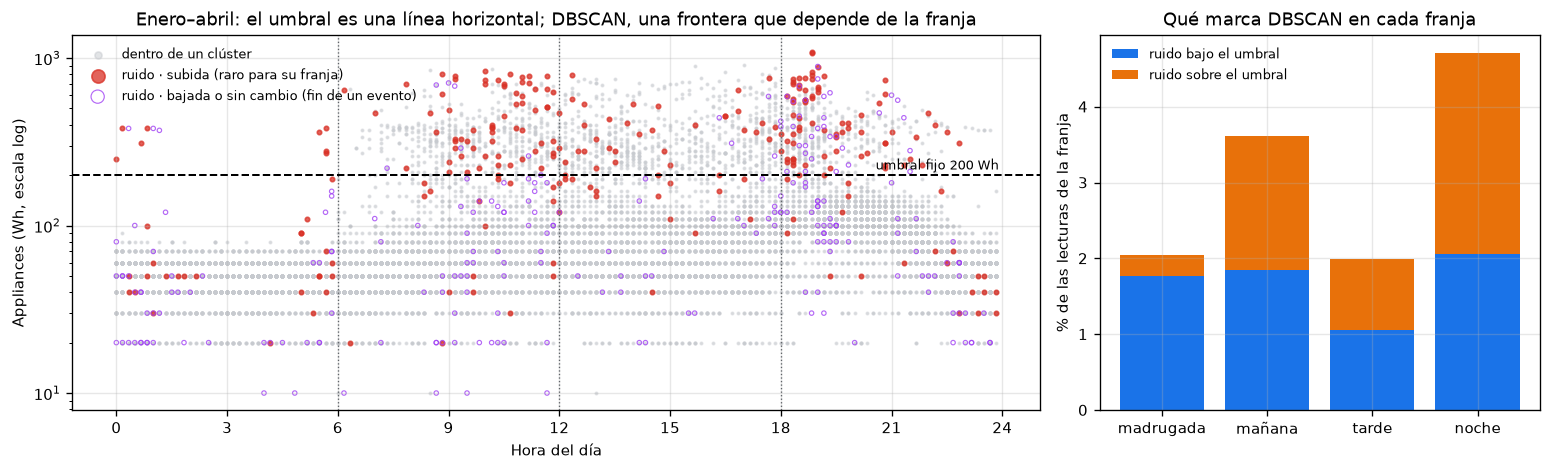

In [18]:
t = dl.loc[TR].copy(); t["ruido"] = RUIDO_B[TR]
rng = np.random.default_rng(RS)
fig, ax = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2.2, 1]})
a = ax[0]
x = t["hora"] + t["date"].dt.minute / 60
sube = t["Appliances"] > t["lag1"]
a.scatter(x[~t.ruido], t.loc[~t.ruido, "Appliances"], s=2, c=COL["claro"], alpha=.5, label="dentro de un clúster")
a.scatter(x[t.ruido & sube], t.loc[t.ruido & sube, "Appliances"], s=7, c=COL["rojo"], alpha=.75,
          label="ruido · subida (raro para su franja)")
a.scatter(x[t.ruido & ~sube], t.loc[t.ruido & ~sube, "Appliances"], s=7, facecolors="none", edgecolors=COL["morado"],
          linewidths=.7, alpha=.8, label="ruido · bajada o sin cambio (fin de un evento)")
a.axhline(UMBRAL, color="black", ls="--", lw=1.2)
a.text(23.9, UMBRAL * 1.08, f"umbral fijo {UMBRAL:.0f} Wh", ha="right", fontsize=8)
for h in (6, 12, 18):
    a.axvline(h, color=COL["gris"], lw=.8, ls=":")
a.set(yscale="log", xlabel="Hora del día", ylabel="Appliances (Wh, escala log)", xticks=range(0, 25, 3),
      title="Enero–abril: el umbral es una línea horizontal; DBSCAN, una frontera que depende de la franja")
a.legend(frameon=False, fontsize=8, loc="upper left", markerscale=3)
b = ax[1]
bajo = FR["% ruido"] * FR["% del ruido bajo el umbral"] / 100
b.bar(FRANJAS, bajo, color=COL[0], label="ruido bajo el umbral")
b.bar(FRANJAS, FR["% ruido"] - bajo, bottom=bajo, color=COL[1], label="ruido sobre el umbral")
b.set(ylabel="% de las lecturas de la franja", title="Qué marca DBSCAN en cada franja")
b.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "D7_contextual.png"); plt.show()

In [19]:
ver = ["date", "Appliances", "lag1", "media_1h", "std_1h"]
mad = t[(t.franja == "madrugada") & t.ruido & (t.Appliances <= UMBRAL)]
tar = t[(t.franja == "tarde") & ~t.ruido & (t.Appliances > UMBRAL)]
print(f"Madrugada · marcadas como ruido y BAJO el umbral: {len(mad)} lecturas. Ejemplos:")
print(mad.sort_values("Appliances", ascending=False)[ver].head(5).round(1).to_string(index=False))
print(f"\nTarde · SOBRE el umbral y dentro de un clúster (normales para DBSCAN): {len(tar)} lecturas. Ejemplos:")
print(tar.sort_values("Appliances", ascending=False)[ver].head(5).round(1).to_string(index=False))

Madrugada · marcadas como ruido y BAJO el umbral: 70 lecturas. Ejemplos:
               date  Appliances  lag1  media_1h  std_1h
2016-04-13 05:50:00         190 120.0     126.7   116.7
2016-04-28 05:50:00         160 270.0      96.7    85.5
2016-04-26 05:50:00         150 280.0      98.3    89.8
2016-04-13 05:40:00         120 360.0     115.0   121.0
2016-01-12 01:20:00         120 370.0     255.0   164.8

Tarde · SOBRE el umbral y dentro de un clúster (normales para DBSCAN): 632 lecturas. Ejemplos:
               date  Appliances  lag1  media_1h  std_1h
2016-01-14 17:00:00         910 740.0     308.3   276.2
2016-04-04 15:40:00         900 720.0     321.7   211.2
2016-04-22 17:50:00         870 380.0     256.7   136.3
2016-04-16 16:30:00         820 730.0     270.0   237.9
2016-01-17 17:30:00         800 380.0     140.0   119.2


**Lo que marca DBSCAN depende de la franja, y no coincide con el umbral:**

| Franja | Consumo mediano | Ruido | Del ruido, bajo 200 Wh | Lecturas > 200 Wh que marca |
|---|---|---|---|---|
| Madrugada | 50 Wh | 2,0 % | **86 %** | **100 %** |
| Mañana | 60 Wh | 3,6 % | 51 % | 14 % |
| Tarde | 80 Wh | 2,0 % | 53 % | **6 %** |
| Noche | 90 Wh | 4,7 % | 44 % | 24 % |

- **De madrugada, DBSCAN ve lo que el umbral no puede ver.** Marca todas las lecturas que superan
  200 Wh, pero el 86 % de lo que señala está **por debajo** del umbral: arranques muy tempranos
  (190 Wh a las 05:50 del 13-abr), o la noche del 12-ene, con 370 Wh a la 01:10 que caen a 120 a la
  01:20. El umbral, en cambio, casi no se dispara de madrugada (0,3 % de las lecturas).
- **En la tarde, DBSCAN deja pasar lo que el umbral grita.** Solo marca el 6 % de las lecturas por
  encima de 200 Wh. Tiene 632 lecturas altas por normales para su franja, entre ellas 910 Wh a las
  17:00 del 14-ene, en medio de un pico que ya iba en 740. Consumir mucho por la tarde es la rutina de esta casa.
- **Buena parte del ruido no son subidas:** entre el 35 % y el 60 % según la franja (el máximo, de
  madrugada) son bajadas o lecturas sin cambio, el final de un evento y no su comienzo. DBSCAN detecta *transiciones* raras en los dos sentidos, y una alarma solo tiene sentido
  en las subidas.

**Para Guardian son dos definiciones de anomalía distintas y complementarias.** El umbral mide
**magnitud**, que habla de costo. DBSCAN por franja mide **rareza en contexto**, que habla de un
aparato olvidado, un arranque inusual o un desperdicio nocturno. El umbral concentra sus avisos en la
tarde (16,9 % de las lecturas), donde consumir mucho es rutina. DBSCAN los reparte entre el 2 % y el
5 % de cada franja.

### Control temporal: ¿la densidad envejece como el umbral?

Se aplica a mayo el modelo de enero–abril de cada franja: el mismo escalador, el mismo `eps` y los
mismos puntos núcleo. Una lectura de mayo es ruido si no tiene ningún núcleo a menos de `eps`.

In [20]:
filas = []
for fr in FRANJAS:
    eps_f, nucleos = MODELO[fr]
    mt = TR & (dl["franja"] == fr).values
    mm = ~TR & (dl["franja"] == fr).values
    dist = NearestNeighbors(n_neighbors=1).fit(nucleos).kneighbors(VD[mm])[0][:, 0]
    RUIDO_B[np.where(mm)[0]] = dist > eps_f
    p90_mayo = np.percentile(dl.loc[mm, "Appliances"], 90)
    filas.append({"franja": fr, "DBSCAN ene–abr": RUIDO_B[mt].mean() * 100, "DBSCAN mayo": (dist > eps_f).mean() * 100,
                  "umbral ene–abr": ALTO[mt].mean() * 100, "umbral mayo": ALTO[mm].mean() * 100,
                  "p90 de mayo (Wh)": p90_mayo})
MY = pd.DataFrame(filas).set_index("franja")
print("% de lecturas marcadas")
print(MY.round(1).to_string())
tot = pd.DataFrame({"DBSCAN": [RUIDO_B[TR].mean() * 100, RUIDO_B[~TR].mean() * 100],
                    "umbral fijo": [ALTO[TR].mean() * 100, ALTO[~TR].mean() * 100]}, index=["ene–abr", "mayo"])
print("\nTotal:"); print(tot.round(1).to_string())
cambio = (tot.loc["mayo"] / tot.loc["ene–abr"] - 1) * 100
print(f"Cambio relativo en mayo: DBSCAN {cambio['DBSCAN']:+.0f} % · umbral fijo {cambio['umbral fijo']:+.0f} %")

% de lecturas marcadas
           DBSCAN ene–abr  DBSCAN mayo  umbral ene–abr  umbral mayo  p90 de mayo (Wh)
franja                                                                               
madrugada             2.0          2.1             0.3          0.2              60.0
mañana                3.6          3.4            12.4         10.5             220.0
tarde                 2.0          1.1            16.9         14.8             260.0
noche                 4.7          1.7            11.2          4.9             140.0

Total:
         DBSCAN  umbral fijo
ene–abr     3.1         10.2
mayo        2.1          7.6
Cambio relativo en mayo: DBSCAN -33 % · umbral fijo -25 %


**La densidad tampoco es inmune a la estación.** En mayo DBSCAN marca el 2,1 % de las lecturas,
frente a 3,1 % en enero–abril: **un 33 % menos**. El umbral fijo baja un 25 % (de 10,2 % a 7,6 %).
Por franja, DBSCAN se sostiene de madrugada (2,0 → 2,1 %) y en la mañana (3,6 → 3,4 %), y cae en la
tarde y sobre todo en la noche (4,7 → 1,7 %), donde el umbral también se desploma (11,2 → 4,9 %).

Se declara tal como sale: DBSCAN **no resuelve** el envejecimiento. Sus puntos núcleo son de invierno
y mayo es más tranquilo: menos días de carga alta (22,7 % → 11,5 %, taller de K-Means) y un p90
nocturno de apenas 140 Wh. Lo que sí conserva es el **reparto**: sigue marcando algo en cada franja,
mientras el umbral de mayo avisa en la tarde (14,8 % de las lecturas) y casi nunca de madrugada (0,2 %). Las dos
definiciones necesitan el mismo remedio: **reajustarse cada mes** con los datos recientes
(hallazgo 10).

---
## Respuestas a las preguntas del enunciado

**1. ¿Cuántos clústeres se formaron?**

- **Días:** uno solo, de 82 días (`eps` = 208 Wh, `min_samples` = 5). Separando por tipo, un
  clúster en cada tipo (82 normales y 24 de carga alta). En las 147 configuraciones de la rejilla
  nunca aparecen dos grupos de tamaño comparable: el máximo son 4 clústers, y los adicionales tienen
  de 3 a 6 días.
- **Lecturas:** con las 30 columnas, uno en el codo y 30 con la mitad del `eps`, que son semanas.
  Con consumo y retardos sin corregir, 14, de los cuales 13 son capas artificiales de la resolución
  del medidor. Ya corregido, un gran grupo con el 95 % de las lecturas y 6 grupos mínimos. Por franja,
  de 1 a 4, siempre con un grupo dominante.

**2. ¿Qué puntos fueron marcados como ruido?**

- **Días:** con un solo `eps`, 54 días, entre ellos **todos los de carga alta**. Separando por tipo,
  30. Hay 22 atípicos robustos: días con unas 4 horas muy por encima de su tipo, 8 de ellos en enero,
  incluidos los tres que el jerárquico aislaba (24-ene, 16-mar, 15-abr). En mayo, 2 días
  desconocidos.
- **Lecturas:** entre el 2 % y el 5 % de cada franja. De madrugada, lecturas modestas a horas
  inusuales (el 86 % bajo el umbral). En las demás franjas, mitad picos y mitad transiciones raras,
  y entre el 35 % y el 60 % del ruido, según la franja, son bajadas o lecturas sin cambio: el final de
  un evento.

**3. ¿Cómo cambia el resultado si se ajustan `eps` o `min_samples`?**

`eps` domina. Por debajo del codo (< 175 Wh en días) DBSCAN fragmenta y marca como ruido la mitad de
los datos; en el codo aparece el gran grupo con la periferia como ruido; por encima de 450 Wh lo
absorbe casi todo. `min_samples` desplaza el codo (208 Wh con 5, 381 con 12) sin cambiar el patrón. En las
lecturas pesan tanto como los parámetros dos decisiones previas: **qué columnas** entran (con las 30
aparecen semanas) y **qué transformación** (sin logaritmo, «raro» significa «grande»).

**4. ¿Qué implicaciones prácticas tendría este agrupamiento en el sector?** Ver el cierre.

---
## Cierre — qué cambia en el diseño de Shiro por causa de estos números

1. **El día de carga alta es un tipo real, pero 2,2 veces más disperso que el normal.** DBSCAN no
   lo ve como grupo con el `eps` de la rutina normal, y sí con el suyo. **La incertidumbre del
   simulador debe depender del tipo de día**, además de la franja (hallazgo 14): el gemelo es menos
   fiable justo los días en que hay cargas que diferir.
2. **Los días atípicos se marcan, no se borran.** Son el 16 % de los días, se concentran en enero
   (8 de 20) y coinciden con los que aisló el jerárquico. Borrarlos le quitaría al gemelo el invierno.
   Marcados, le dicen al agente cuándo no confiar en su estimación del tipo de día.
3. **«Día desconocido» es una señal nueva para el MDP.** Si el día en curso no tiene vecinos densos
   en la historia (2 de 26 en mayo), el simulador no ha visto nada parecido y la política debe ser
   conservadora.
4. **Guardian tendrá dos tipos de alarma.** El **umbral** (magnitud, costo) y **DBSCAN por franja**
   (rareza en contexto: aparato olvidado, arranque inusual, desperdicio nocturno), avisando solo en las
   subidas. De madrugada, DBSCAN ve lo que el umbral no ve. En la tarde, deja pasar lo que el umbral
   marca por rutina.
5. **Ninguna de las dos definiciones es inmune a la estación.** En mayo DBSCAN marca un 33 % menos y
   el umbral un 25 % menos. Las dos se reajustan cada mes (hallazgo 10).
6. **Tres lecciones de método para todo el proyecto:**
   - Con todas las columnas, DBSCAN encuentra el calendario (semanas), no comportamientos.
   - Los datos cuantizados (resolución de 10 Wh) crean densidad artificial, que se corrige con
     dithering dentro de la resolución del medidor.
   - Un solo `eps` no sirve para grupos de densidades distintas: separar por grupos es parte del
     método, y la elección del grupo se justifica con datos.